# Automotive Price Prediction & Vehicle Classification
## End-to-End Data Science Pipeline

| | |
|---|---|
| **Dataset** | Car Features and MSRP (Kaggle — CooperUnion) |
| **Regression Target** | MSRP (Manufacturer's Suggested Retail Price) |
| **Classification Target** | Vehicle Size (Compact / Midsize / Large) |
| **Total Phases** | 9 |

---

# Phase 1: Dataset Acquisition & Initial Exploration

## 1.1 Load and Inspect

This cell loads the dataset from the local CSV file and displays its structure 
including shape, column names, data types, memory usage, and missing value counts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Quick Sanity Check
df = pd.read_csv("data.csv")
print(df.head(10))
print(df.info())
print(df.shape)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'

## Observations from Initial Inspection

The dataset contains **11,914 rows and 16 columns**, covering car specifications 
and pricing data from multiple manufacturers. Out of 16 columns, **8 are numerical** 
(Year, Engine HP, Engine Cylinders, Number of Doors, highway MPG, city mpg, 
Popularity, MSRP) and **8 are categorical** (Make, Model, Engine Fuel Type, 
Transmission Type, Driven_Wheels, Market Category, Vehicle Size, Vehicle Style).

Missing values are present in 5 columns: **Market Category has the most with 
3,742 missing values (31.4%)**, followed by Engine HP (69), Engine Cylinders (30), 
Number of Doors (6), and Engine Fuel Type (3). These will require careful 
imputation strategies.

The dataset occupies approximately **6.08 MB** in memory. The target variables 
identified are **MSRP** (continuous — for regression) and **Vehicle Size** 
(categorical: Compact/Midsize/Large — for classification).

## 1.2 Data Card

| Field | Details |
|---|---|
| **Source URL** | https://www.kaggle.com/datasets/CooperUnion/cardataset |
| **Licence** | CC0 — Public Domain |
| **Collection Method** | Scraped from Edmunds and Twitter; data represents manufacturer-reported specifications |
| **Collection Period** | Model years 1990 to 2017 |
| **Known Limitations** | MSRP reflects original manufacturer price — does not account for depreciation, dealer markups, or regional pricing differences |
| **Sampling Biases** | Dataset is heavily skewed toward US market vehicles and popular brands; rare or regional manufacturers are underrepresented. Older models (pre-2000) have fewer entries than recent years |


## 1.3 Statistical Snapshot

This cell runs `df.describe(include="all")` to generate a full statistical 
summary of all 16 columns — both numerical and categorical — to identify 
skewness, implausible values, and data quality issues before modelling.

In [ ]:
df.describe(include="all") # statistical summary of every column

## Observations from Statistical Snapshot

### Mean vs Median Check (>20% difference flags skewness)

| Column | Mean | Median | Difference % | Flag |
|---|---|---|---|---|
| MSRP | 40,594 | 29,995 | 35.3% | Right-skewed — luxury/exotic cars inflate the mean |
| Engine HP | 249 | 227 | 9.7% |   Acceptable |
| Popularity | 1,554 | 1,385 | 12.2% | Acceptable |
| highway MPG | 26.6 | 26 | 2.3% | Acceptable |
| city mpg | 19.7 | 18 | 9.4% | Acceptable |

### Physically Implausible Values

| Column | Issue | Explanation |
|---|---|---|
| Engine Cylinders | min = **0.0** | No real combustion engine has 0 cylinders — likely electric vehicle recorded incorrectly |
| highway MPG | max = **354** | No conventional car achieves 354 MPG — likely a data entry error |
| city mpg | max = **137** | Implausibly high for a conventional vehicle |
| MSRP | max = **$2,065,902** | Plausible — corresponds to ultra-luxury exotic cars |
| Engine HP | max = **1001** | Plausible — high-performance supercars exceed 1000 HP |

### Key Takeaway
MSRP is heavily right-skewed due to exotic cars and will require log transformation 
before regression modelling. Engine Cylinders minimum of 0 and extremely high MPG 
values will be treated as outliers in Phase 3.

## 1.4 Target Variable Definition

### Regression Target — MSRP
- **Type:** Continuous numerical variable
- **Physical Meaning:** MSRP (Manufacturer's Suggested Retail Price) represents 
the price in US Dollars ($) that a manufacturer recommends a dealer charge for 
a vehicle.
- **Justification:** MSRP is a suitable regression target because it varies 
continuously from $2,000 to $2,065,902 and is directly influenced by engineering 
features such as Engine HP, Engine Cylinders, and fuel efficiency (MPG). 
Predicting MSRP from these features is a meaningful and well-defined 
engineering problem.

### Classification Target — Vehicle Size
- **Type:** Categorical variable with 3 ordered classes
- **Categories:** Compact / Midsize / Large
- **Justification:** Vehicle Size is a natural categorical column already present 
in the dataset — no binning or derivation was required. The three classes 
represent physically meaningful size categories defined by the manufacturer, 
making this a valid and domain-justified classification target.

## 1.5. Class balance check

This cell calculates imbalance ratio, necessary for modeling, and plots a bar chart of classification target.

In [ ]:
counts = df["Vehicle Size"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, width=0.3, color='purple', edgecolor='black', linewidth=0.5)

plt.title("Distribution of Vehicle Size Classes", fontsize=12)
plt.xlabel("Category", fontsize = 12)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Imbalance Ratio
ratio = counts.max() / counts.min()
print(f"Imbalance ratio: {ratio:.2f}:1")

## Class Balance Check

The classification target **Vehicle Size** has the following class distribution:
- **Compact:** 4,764 vehicles (40.0%)
- **Midsize:** 4,028 vehicles (33.8%)
- **Large:** 3,122 vehicles (26.2%)

The imbalance ratio (majority ÷ minority) = **1.72:1**, which is well below the 
5:1 threshold. Therefore, the dataset is **sufficiently balanced** and no special 
handling (such as oversampling or undersampling) is required during model evaluation 
in Phase 7.

# Phase 2: Exploratory Data Analysis

## 2.1 Univariate Distributions

### Theory
Skewness measures the asymmetry of a distribution around its mean:

$$\gamma_1 = \frac{E\left[(X - \mu)^3\right]}{\sigma^3}$$

- $\gamma_1 > 1$ → Right-skewed (long tail on right)
- $\gamma_1 < -1$ → Left-skewed (long tail on left)
- $\gamma_1 \approx 0$ → Symmetric

Kurtosis measures how heavy the tails are compared to a normal distribution:

$$\gamma_2 = \frac{E\left[(X - \mu)^4\right]}{\sigma^4} - 3$$

- $\gamma_2 > 1$ → Heavy tails (more extreme outliers)
- $\gamma_2 < -1$ → Light tails (fewer extreme outliers)
- $\gamma_2 \approx 0$ → Normal tails

This cell plots a histogram with KDE overlay for every numerical 
feature and computes skewness and kurtosis values.

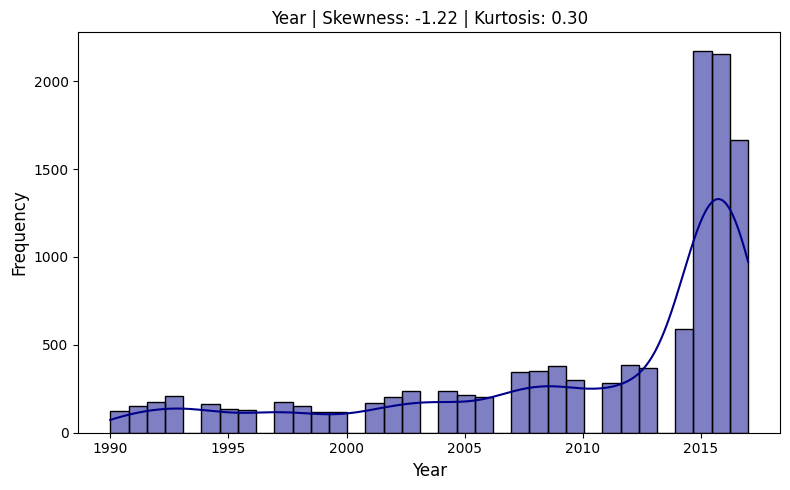

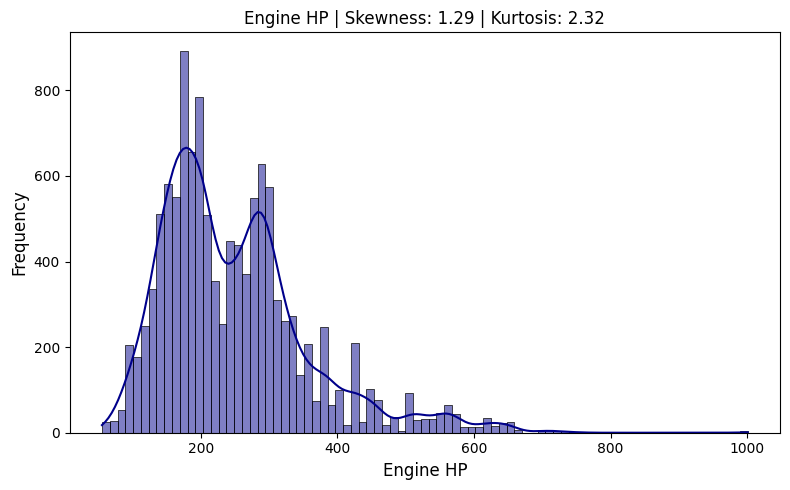

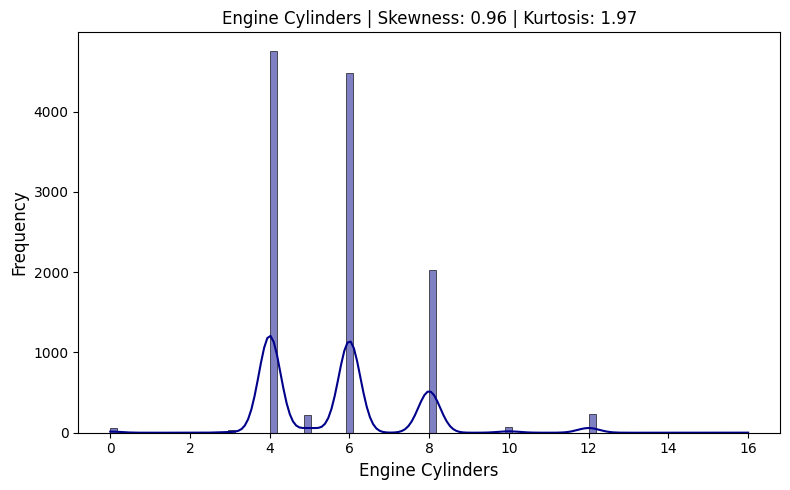

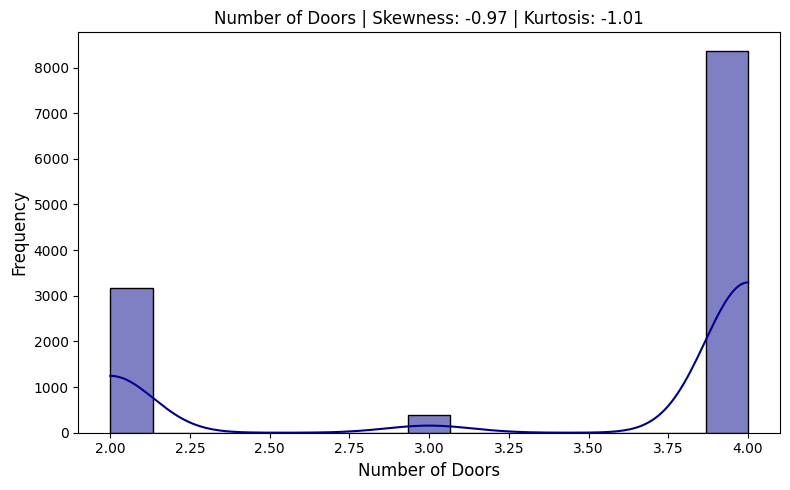

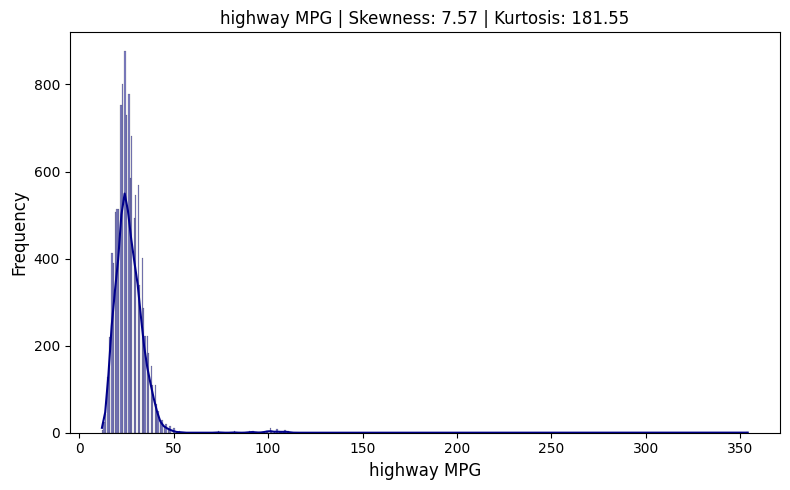

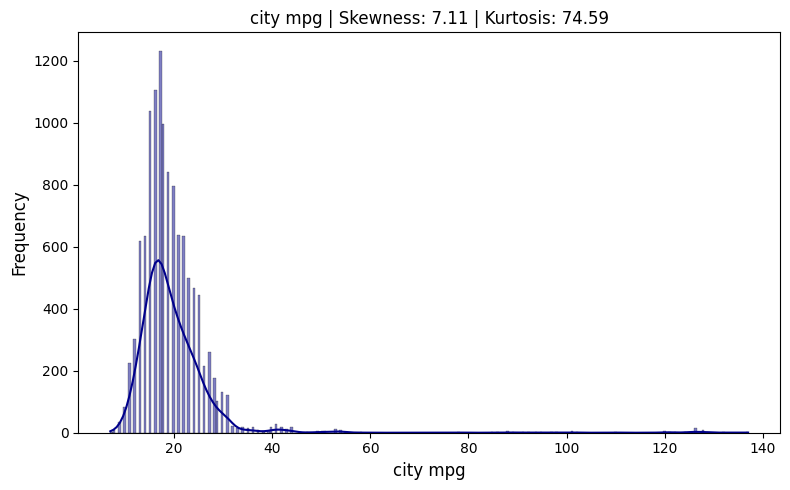

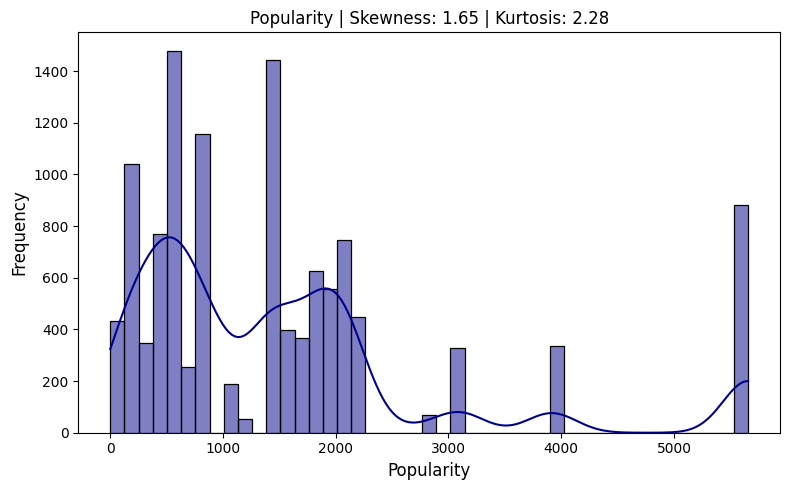

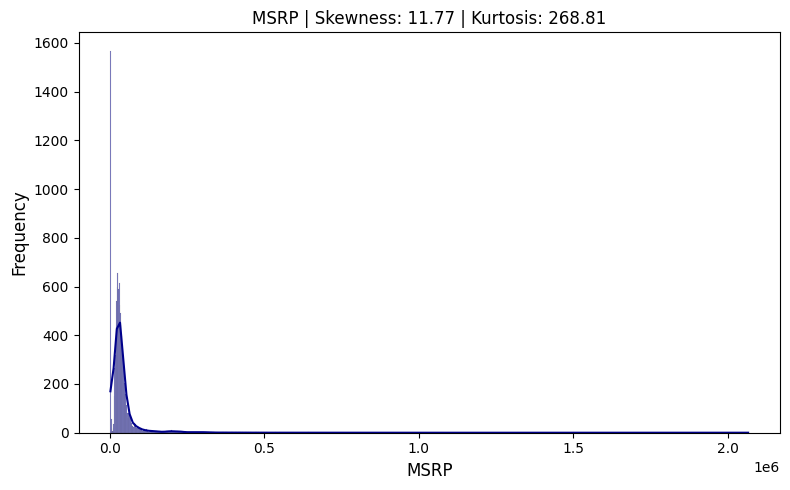

In [ ]:
from scipy import stats

num_cols = df.select_dtypes(include='number').columns # Gets all numerical columns automatically

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True, color='darkblue') # drop.na() drops missing values
    
    skewness = stats.skew(df[col].dropna())
    kurtosis = stats.kurtosis(df[col].dropna())
    
    plt.title(f"{col} | Skewness: {skewness:.2f} | Kurtosis: {kurtosis:.2f}", fontsize=12)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.tight_layout()
    plt.show()

## Observations from Univariate Distributions

| Feature | Skewness (γ1) | Kurtosis (γ2) | Distribution Shape |
|---|---|---|---|
| Year | -1.22 | 0.30 | Left-skewed — more recent model years dominate |
| Engine HP | 1.29 | 2.32 | Right-skewed — few high-performance cars pull mean up |
| Engine Cylinders | 0.96 | 1.97 | Slightly right-skewed — most cars have 4-6 cylinders |
| Number of Doors | -0.97 | -1.01 | Slightly left-skewed, light tails — most cars have 4 doors |
| highway MPG | 7.57 | 181.55 | Severely right-skewed, extremely heavy tails — a few hybrid/electric vehicles with implausibly high MPG values |
| city mpg | 7.11 | 74.59 | Severely right-skewed, very heavy tails — same issue as highway MPG |
| Popularity | 1.65 | 2.28 | Right-skewed — few brands dominate Twitter mentions |
| MSRP | 11.77 | 268.81 | Most severely skewed — exotic cars worth millions create extreme right tail |

### Key Takeaways
- **MSRP, highway MPG, and city mpg** are severely right-skewed (γ1 > 1) 
and will require **log transformation** before regression modelling to reduce 
the influence of extreme values.
- **highway MPG (γ2 = 181.55) and MSRP (γ2 = 268.81)** have extremely heavy 
tails indicating dangerous outliers that must be treated in Phase 3.
- **Number of Doors** has light tails (γ2 = -1.01) — values are tightly 
clustered around 2 and 4 with almost no variation.
- **Year** is left-skewed (γ1 = -1.22) — the dataset is heavily biased 
toward recent model years (2010–2017).

## 2.2 Categorical Analysis

This cell plots a bar chart of value counts for every categorical 
feature sorted by frequency, and identifies rare categories 
comprising less than 1% of the data (< 119 rows).

**Note:** The Model column (915 unique values) is excluded from 
visualization as it is essentially an ID column and is not suitable 
for bar chart analysis. It will be dropped during Phase 3 preprocessing.

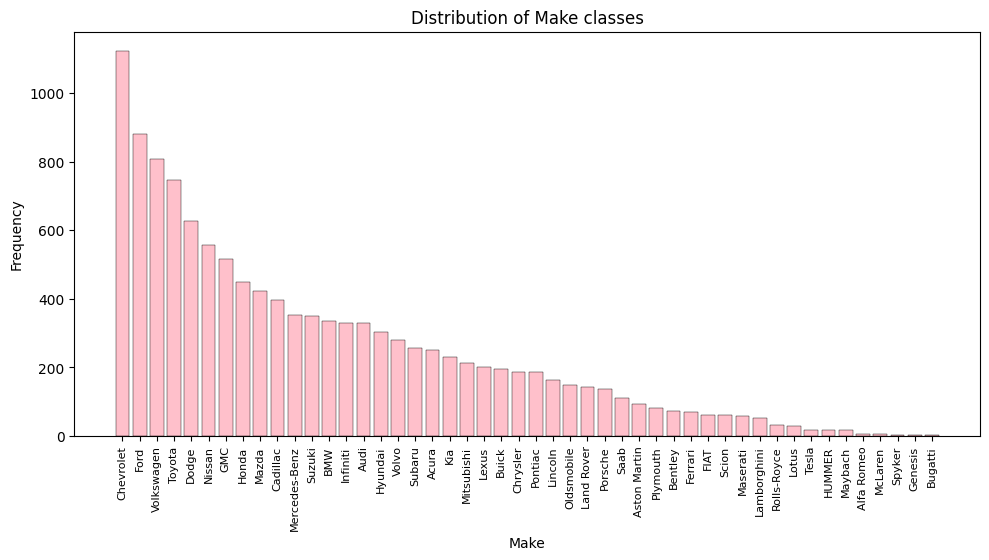


Rare categories in Make (< 1%):
Make
Saab            111
Aston Martin     93
Plymouth         82
Bentley          74
Ferrari          69
FIAT             62
Scion            60
Maserati         58
Lamborghini      52
Rolls-Royce      31
Lotus            29
Tesla            18
HUMMER           17
Maybach          16
Alfa Romeo        5
McLaren           5
Spyker            3
Genesis           3
Bugatti           3
Name: count, dtype: int64


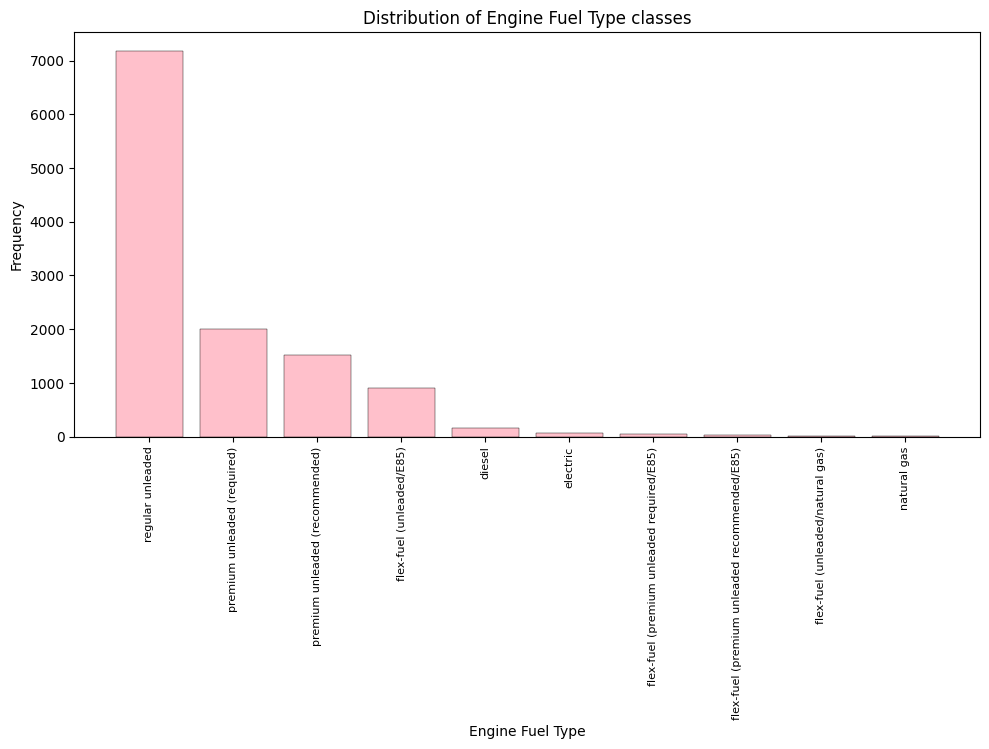


Rare categories in Engine Fuel Type (< 1%):
Engine Fuel Type
electric                                        66
flex-fuel (premium unleaded required/E85)       54
flex-fuel (premium unleaded recommended/E85)    26
flex-fuel (unleaded/natural gas)                 6
natural gas                                      2
Name: count, dtype: int64


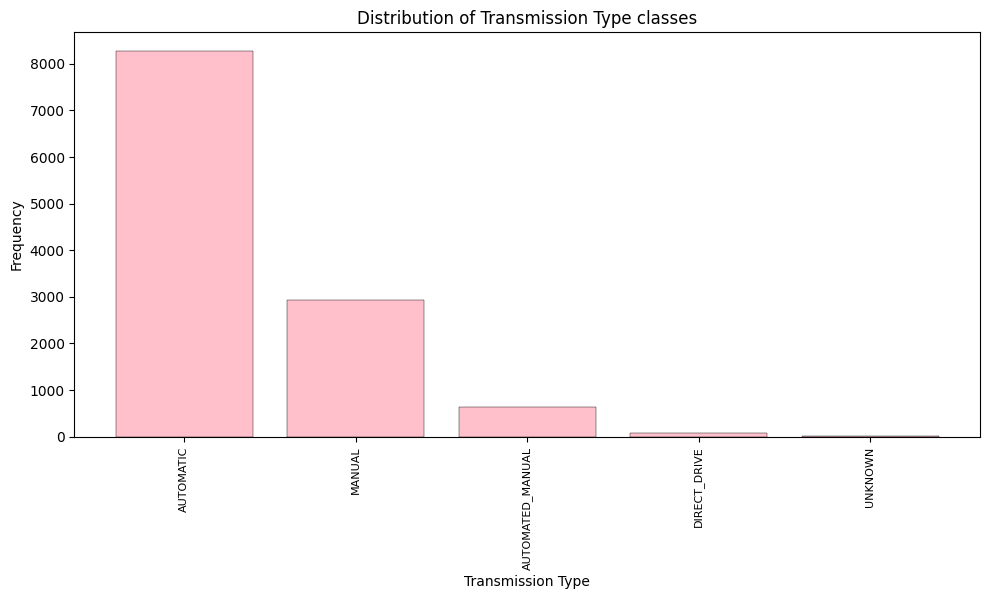


Rare categories in Transmission Type (< 1%):
Transmission Type
DIRECT_DRIVE    68
UNKNOWN         19
Name: count, dtype: int64


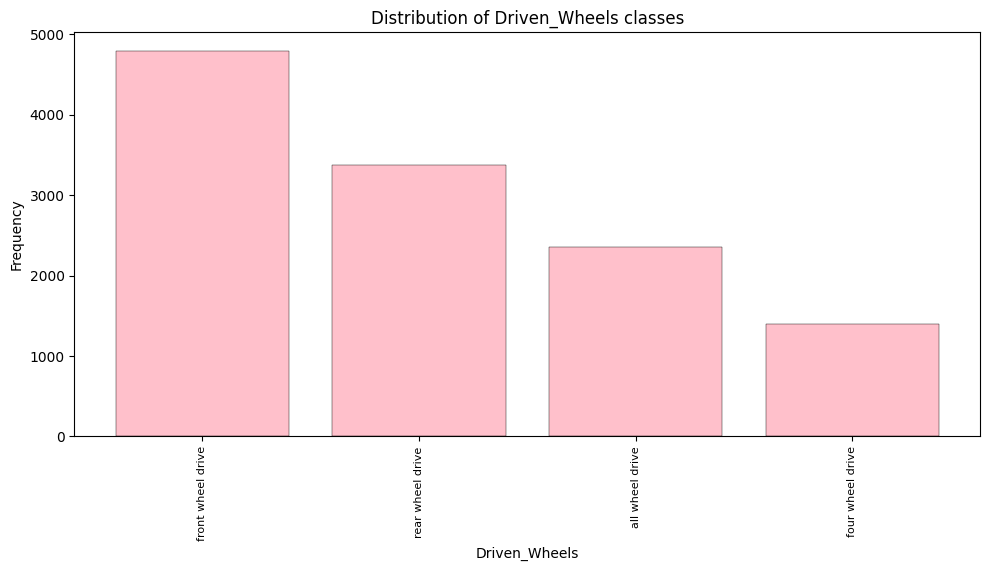

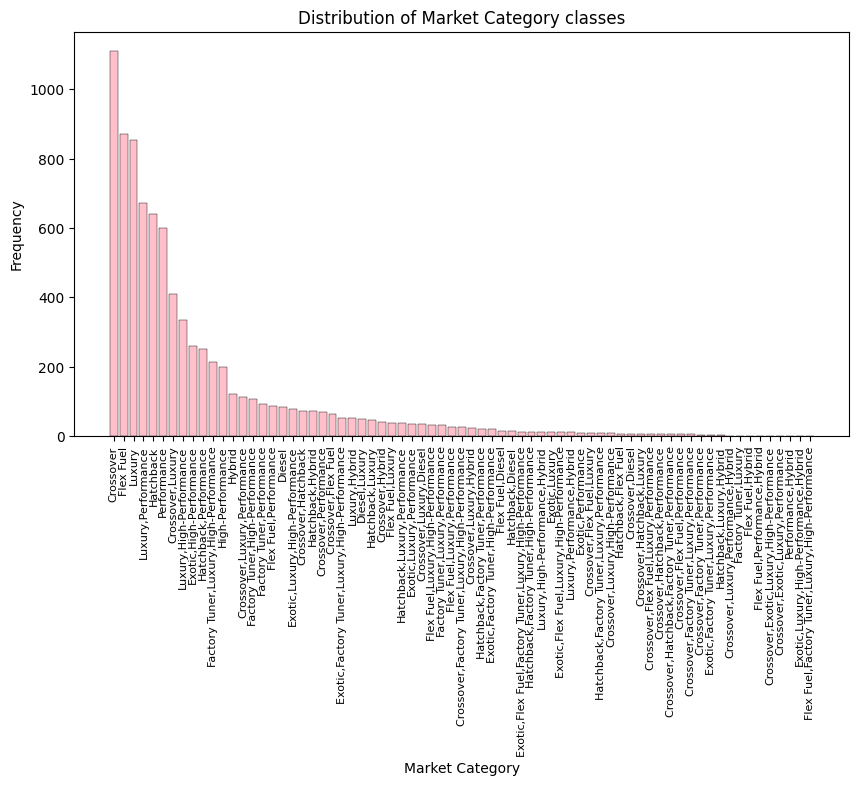


Rare categories in Market Category (< 1%):
Market Category
Crossover,Luxury,Performance                              113
Factory Tuner,High-Performance                            106
Factory Tuner,Performance                                  92
Flex Fuel,Performance                                      87
Diesel                                                     84
Exotic,Luxury,High-Performance                             79
Crossover,Hatchback                                        72
Hatchback,Hybrid                                           72
Crossover,Performance                                      69
Crossover,Flex Fuel                                        64
Exotic,Factory Tuner,Luxury,High-Performance               52
Luxury,Hybrid                                              52
Diesel,Luxury                                              51
Hatchback,Luxury                                           46
Crossover,Hybrid                                           42
Flex Fuel,

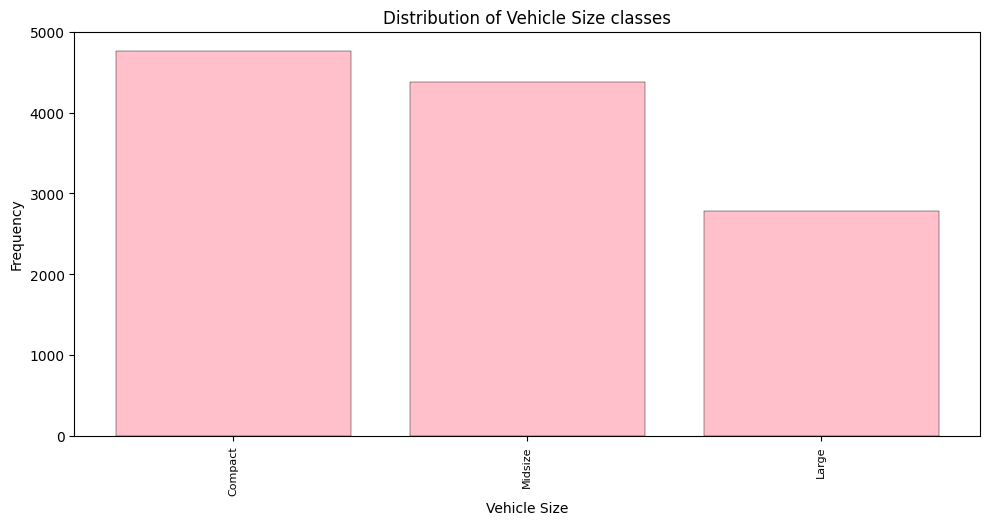

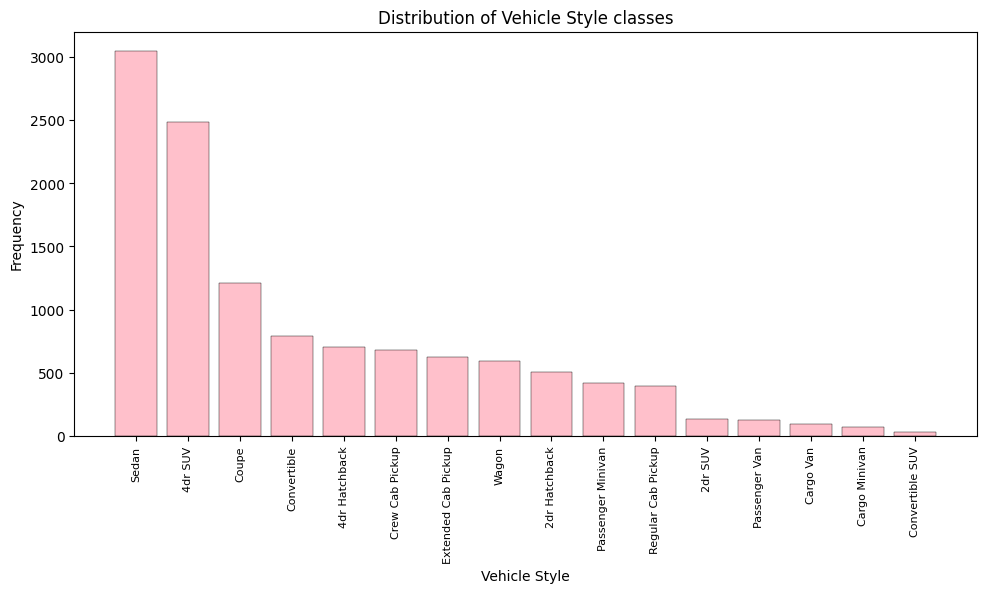


Rare categories in Vehicle Style (< 1%):
Vehicle Style
Cargo Van          95
Cargo Minivan      71
Convertible SUV    29
Name: count, dtype: int64


In [ ]:
cat_cols = df.select_dtypes(include='object').columns # Gets all categorical columns automatically
# columns to skip — too many unique values
skip_cols = ['Model']

for col in cat_cols:
    if col in skip_cols:
        continue          # skip this column entirely
    
    plt.figure(figsize=(10, 5))
   
    counts = df[col].value_counts()
    
    bars = plt.bar(counts.index, counts.values, color = 'pink', edgecolor = 'black', linewidth = 0.3)
    plt.title(f"Distribution of {col} classes", fontsize = 12)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.xticks(rotation=90, fontsize=8) # It rotates x-axis labels 90 degrees vertically and makes them smaller so they don't overlap each other
    plt.show()
    
    # Display the rare categories
    rare = counts[counts < 119]
    if len(rare) > 0:
        print(f"\nRare categories in {col} (< 1%):")
        print(rare)

## Observations from Categorical Analysis

### Rare Categories Identified (< 1% of data = < 119 rows)

| Column | Rare Categories | Action in Phase 3 |
|---|---|---|
| **Make** | Saab, Aston Martin, Plymouth, Bentley, Ferrari, FIAT, Scion, Maserati, Lamborghini, Rolls-Royce, Lotus, Tesla, Spyker, Genesis, Bugatti | Group into "Other" category |
| **Engine Fuel Type** | electric, flex-fuel variants, natural gas | Group into "Other" category |
| **Transmission Type** | DIRECT_DRIVE, UNKNOWN | Group into "Other" or drop |
| **Market Category** | 40+ rare combinations | Drop column — too many unique combinations |
| **Vehicle Style** | Cargo Van, Cargo Minivan, Convertible SUV | Group into "Other" category |

### Key Observations

- **Make** is heavily dominated by Chevrolet (1,123 cars) — 15 out of 48 
brands are rare and will need grouping.
- **Engine Fuel Type** is dominated by regular unleaded (7,172 cars = 60%) — 
5 fuel types are rare including electric vehicles.
- **Transmission Type** is dominated by AUTOMATIC (8,266 cars = 69%) — 
DIRECT_DRIVE and UNKNOWN are rare and will be grouped.
- **Market Category** has 71 unique combinations — extremely high cardinality. 
This column will be dropped in Phase 3 or frequency encoded.
- **Vehicle Size** is well balanced — Compact (4,764), Midsize (4,386), 
Large (2,764) — confirming our classification target is suitable.
- **Vehicle Style** has 3 rare body types that will be grouped into "Other" 
during Phase 3 encoding.
- **Driven Wheels** and **Vehicle Style** show no surprising distributions — 
front wheel drive dominates as expected for a US market dataset.

## 2.3 Correlation Matrix

This cell computes the Pearson correlation matrix for all numerical 
features and visualizes it as an annotated heatmap.

### Pearson Correlation Formula
The Pearson correlation coefficient between two variables x and y:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

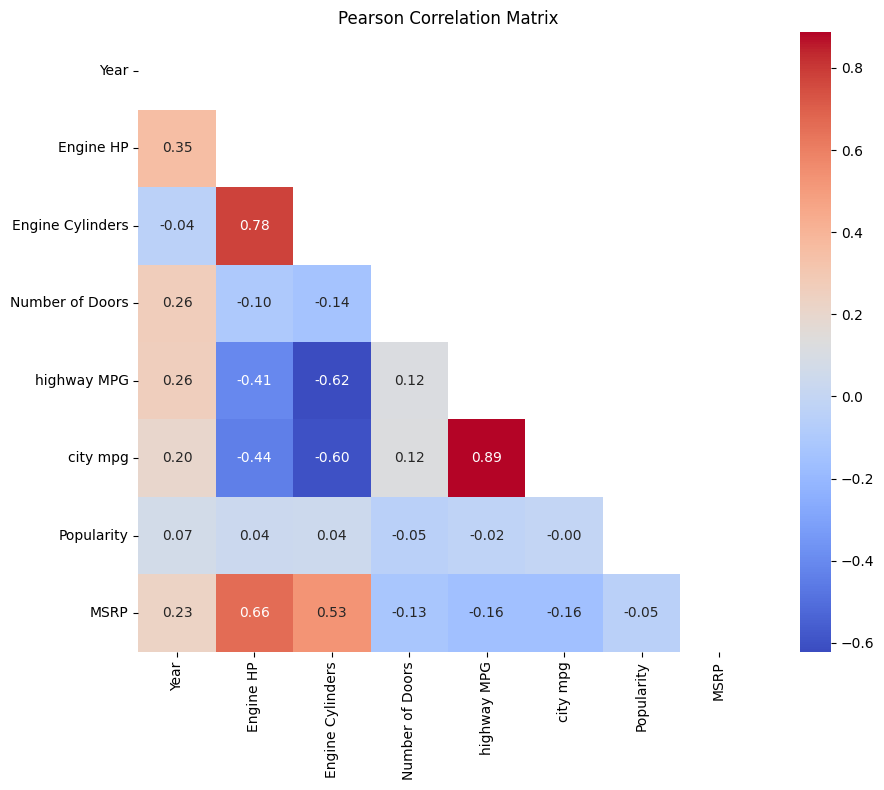

In [ ]:
# select all numerical columns at once
corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr)) # Mask hides the upper triangle of the correlation matrix to avoid showing the same correlation value twice

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, 
            cmap="coolwarm", fmt=".2f", square=True)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

## Observations from Correlation Matrix

### Top 3 Positive Correlations with MSRP
| Feature | Correlation with MSRP | Interpretation |
|---|---|---|
| Engine HP | 0.66 | Strong positive — more powerful engines cost more |
| Engine Cylinders | 0.53 | Moderate positive — more cylinders means higher price |
| Year | 0.23 | Weak positive — newer models tend to cost more |

### Top 3 Negative Correlations with MSRP
| Feature | Correlation with MSRP | Interpretation |
|---|---|---|
| city mpg | -0.16 | Weak negative — fuel efficient cars tend to be cheaper |
| highway MPG | -0.16 | Weak negative — same pattern as city mpg |
| Number of Doors | -0.13 | Weak negative — more doors slightly associated with lower price |

### Multicollinearity Warning — |r| > 0.8
| Feature Pair | Correlation | Action |
|---|---|---|
| highway MPG vs city mpg | **0.89** | Strong multicollinearity — these two features are nearly identical. One may need to be dropped in Phase 5 to avoid destabilising regression coefficients |
| Engine HP vs Engine Cylinders | **0.78** | Approaching multicollinearity threshold — monitor carefully |

### Key Takeaway
Engine HP is the strongest predictor of MSRP (r = 0.66), confirming 
that more powerful cars are significantly more expensive. The near-perfect 
correlation between highway MPG and city mpg (r = 0.89) indicates 
redundant features that will be addressed during feature selection in Phase 5.

## 2.4 Bivariate Plots

This section produces three types of bivariate plots: scatter plots of top 5 
features vs MSRP with trend lines, box plots of numerical features grouped by 
Vehicle Size, and a pair plot of top 5 features coloured by Vehicle Size.

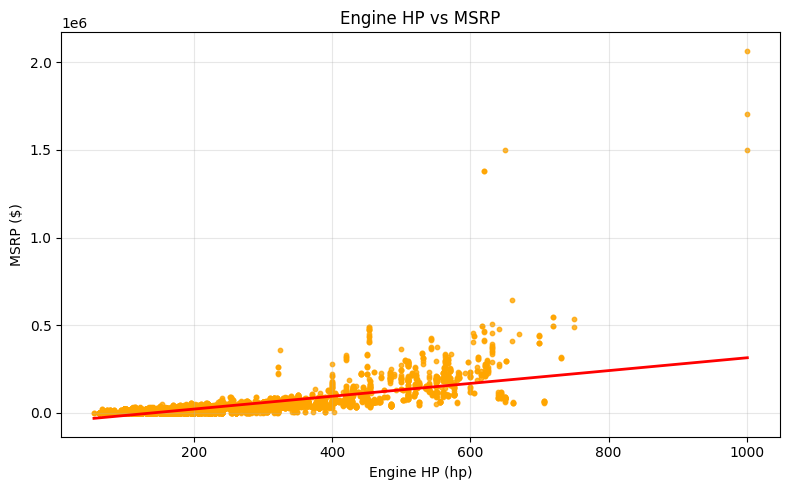

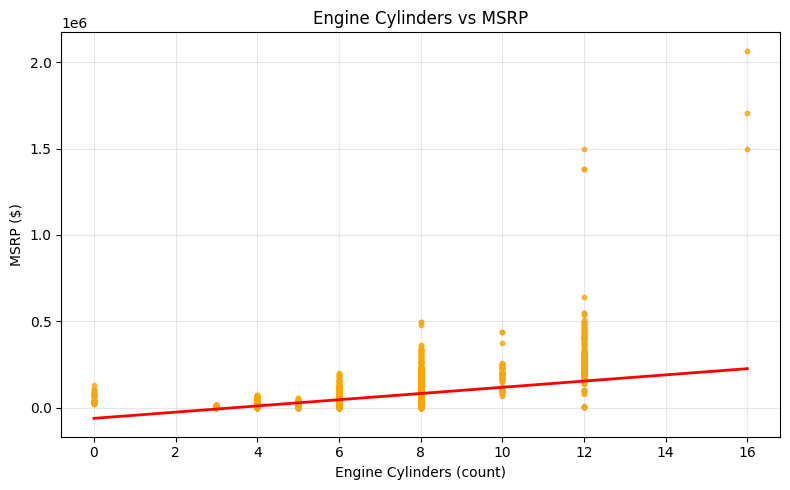

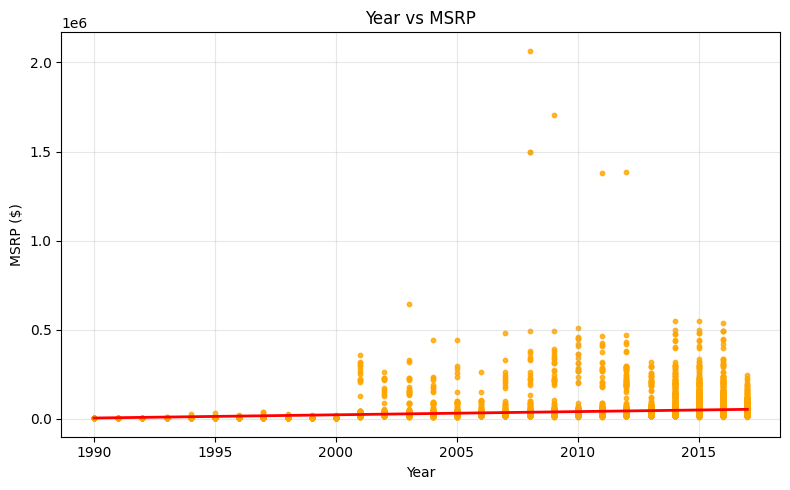

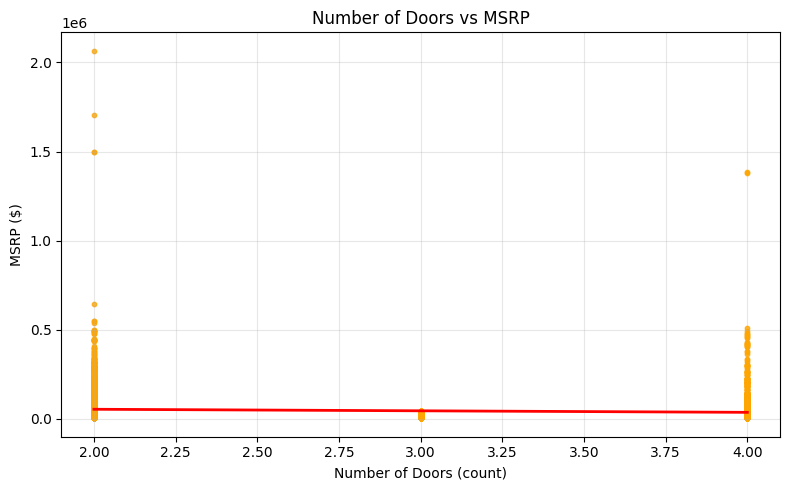

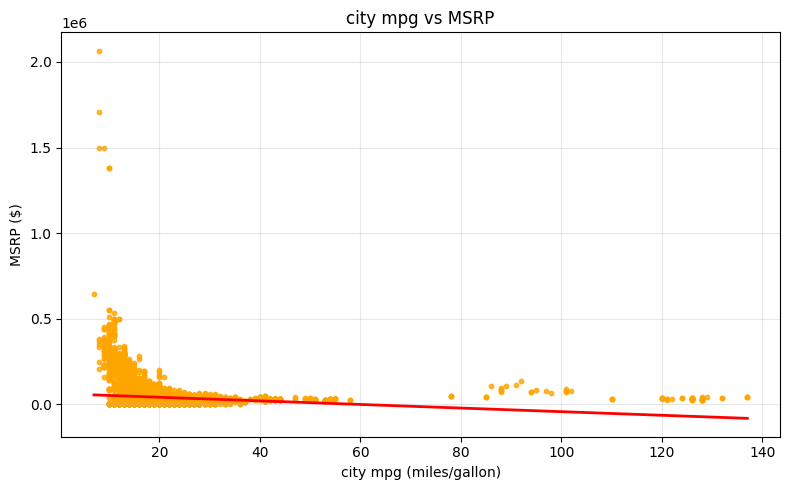

In [ ]:
# Based on their correlation

top5_features= {
    'Engine HP': 'Engine HP (hp)',
    'Engine Cylinders': 'Engine Cylinders (count)',
    'Year': 'Year',
    'Number of Doors': 'Number of Doors (count)',
    'city mpg': 'city mpg (miles/gallon)'
}

for feature in top5_features:
    temp = df[[feature, 'MSRP']].dropna()  # drop missing from both together to make them equally sized
    
    plt.figure(figsize=(8, 5))
    plt.scatter(temp[feature], temp["MSRP"], 
                color='orange',
                alpha=0.8,
                s=10)
    
    # Trend line
    coeffs = np.polyfit(temp[feature], temp['MSRP'], deg=1)
    trend = np.poly1d(coeffs)
    x_sorted = np.sort(temp[feature])
    plt.plot(x_sorted, trend(x_sorted), color='red', linewidth=2)
    
    plt.title(f"{feature} vs MSRP")
    plt.xlabel(top5_features[feature])
    plt.ylabel("MSRP ($)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show() 

### Observations from Scatter Plots

| Feature | Trend | Interpretation |
|---|---|---|
| Engine HP vs MSRP | ↗ Positive | Strong upward trend confirms r = 0.66 — more powerful engines cost significantly more |
| Engine Cylinders vs MSRP | ↗ Positive | Upward trend confirms r = 0.53 — more cylinders associated with higher price |
| Year vs MSRP | ↗ Weak positive | Slight upward trend confirms r = 0.23 — newer models tend to cost more |
| Number of Doors vs MSRP | → Flat | Almost no trend confirms r = -0.13 — number of doors has negligible effect on price |
| city mpg vs MSRP | ↘ Negative | Downward trend confirms r = -0.16 — fuel efficient cars tend to be cheaper |

**Outlier Note:** Extreme MSRP outliers (exotic cars > $500,000 such as Bugatti 
and Lamborghini) are visible in all scatter plots as isolated dots at the top. 
These pull the trend lines upward making them less representative of the majority 
of cars. These outliers will be treated during Phase 3 using IQR method before 
regression modelling in Phase 6.

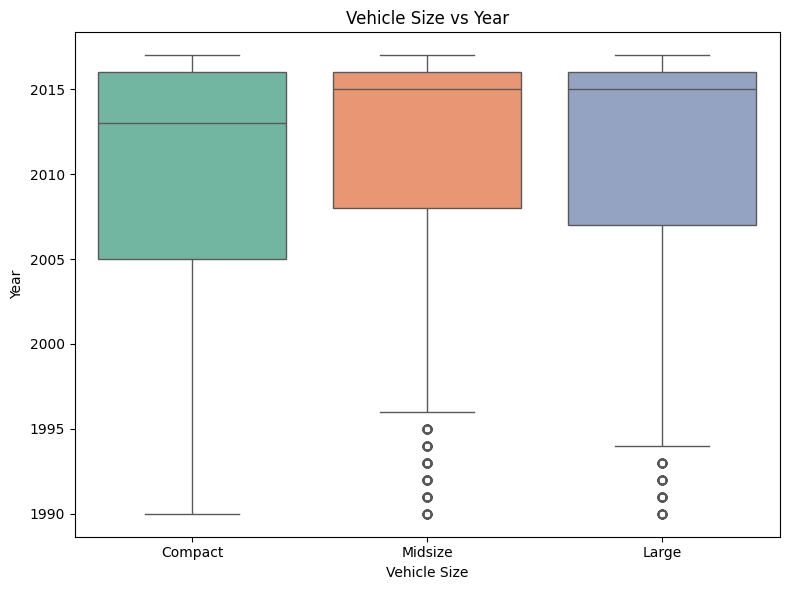

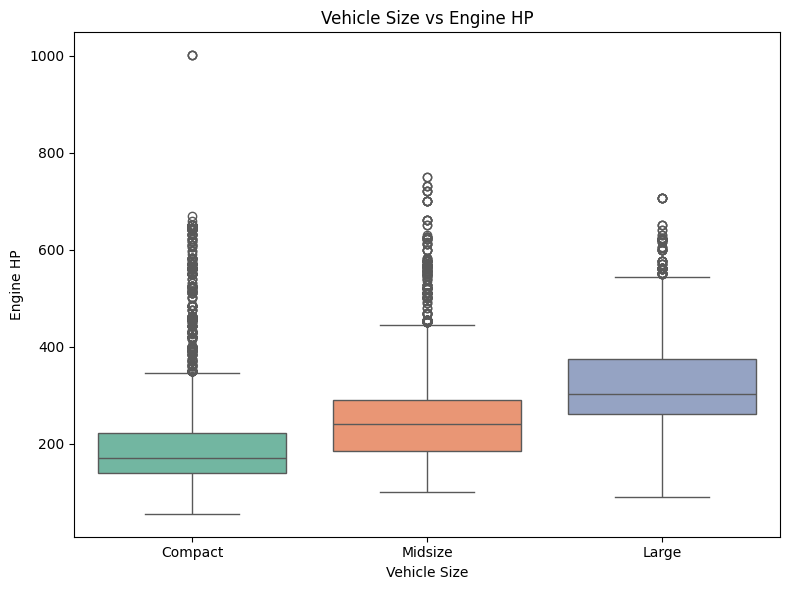

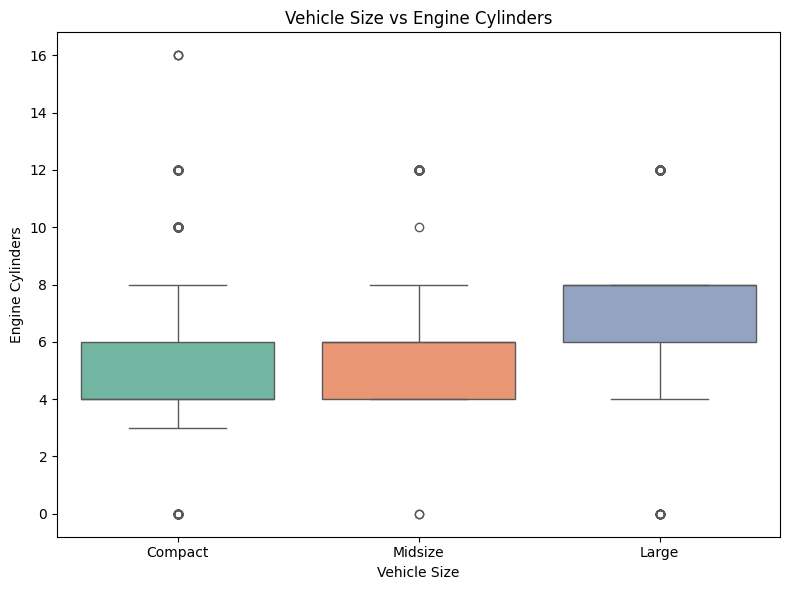

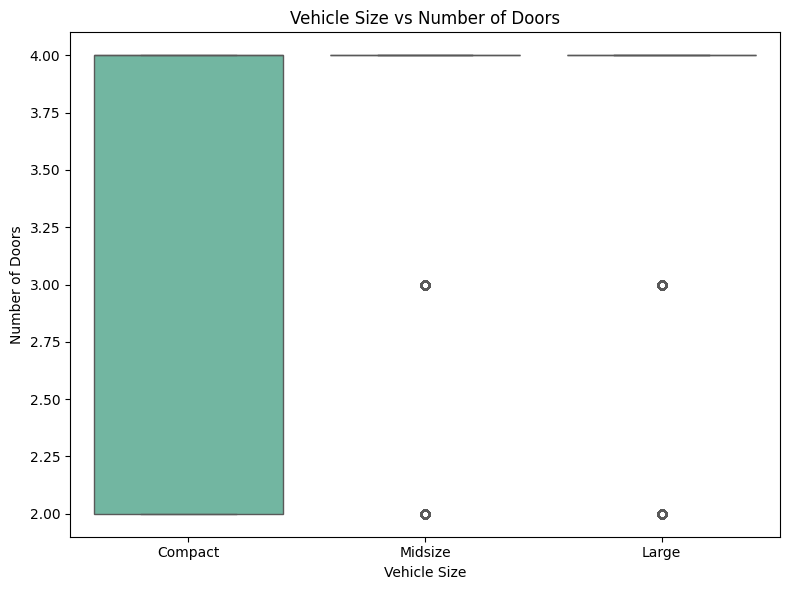

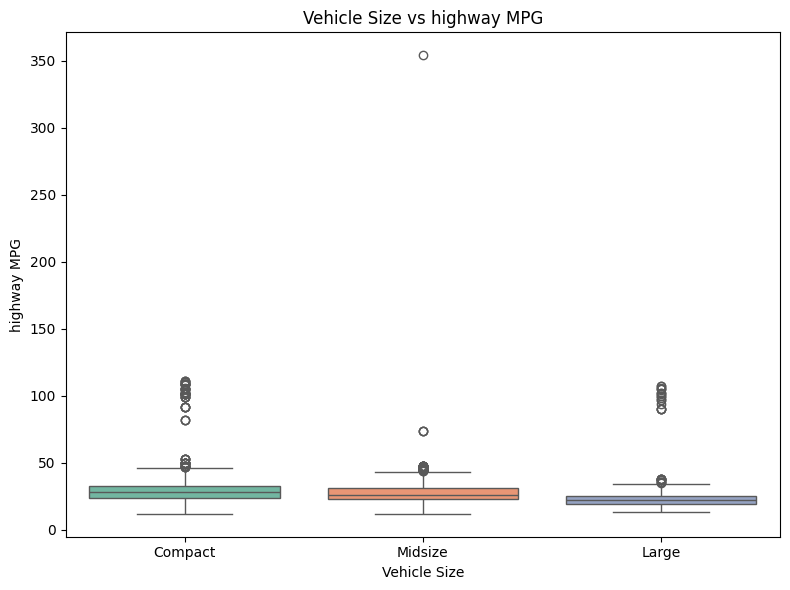

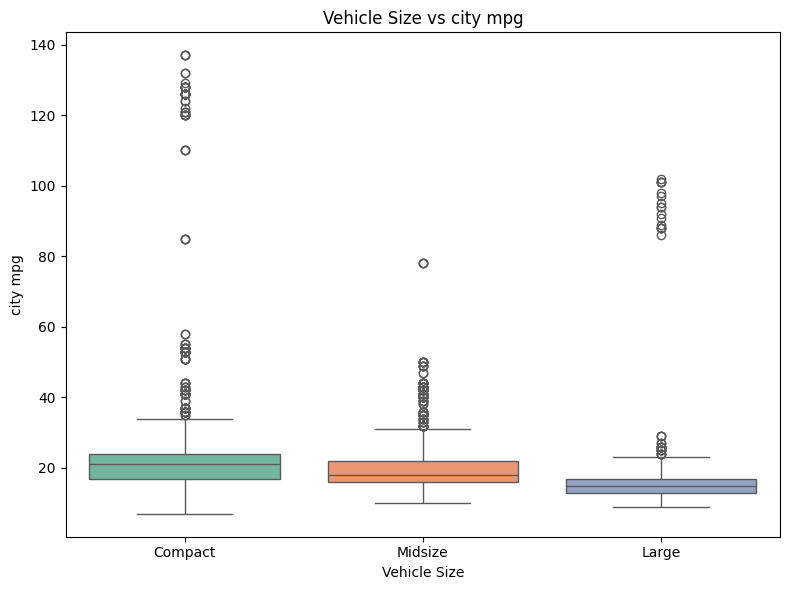

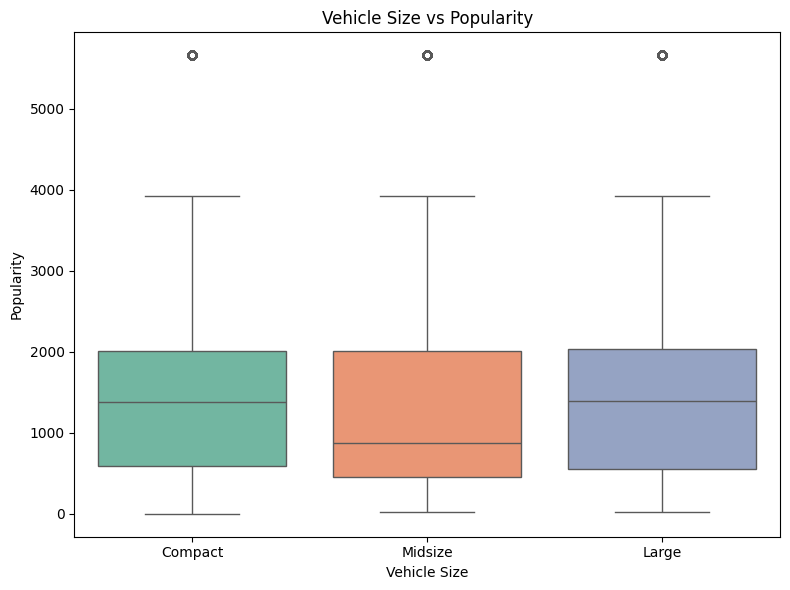

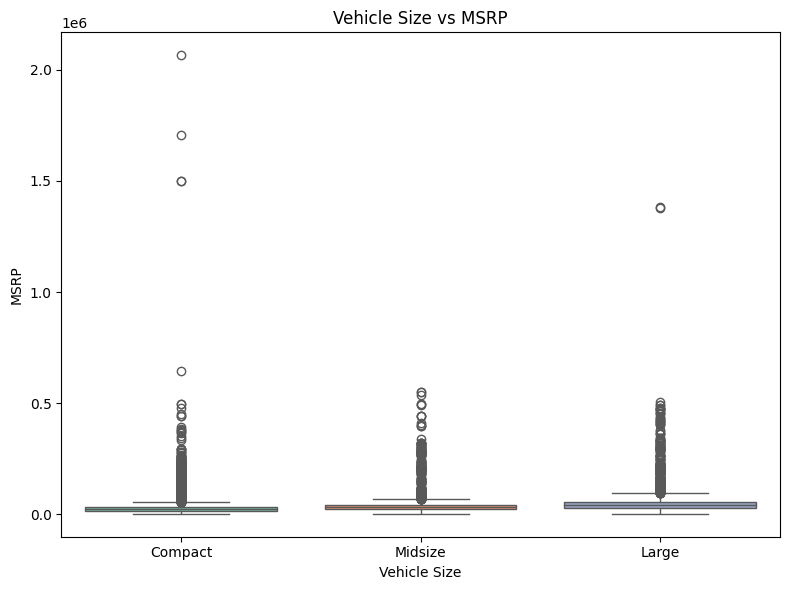

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for feature in num_cols:
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Vehicle Size', y=feature, data=df, 
            hue='Vehicle Size', palette='Set2', legend=False)
    
    plt.title(f"Vehicle Size vs {feature}")
    plt.xlabel("Vehicle Size")
    plt.ylabel(feature)
    
    plt.tight_layout()

## Observations from Box Plots

| Feature | Separation Between Classes | Useful for Classification? |
|---|---|---|
| Engine HP |  Clear — Large cars have highest HP (median ~300), Compact lowest (~180) |  Yes |
| Engine Cylinders |  Clear — Large cars have more cylinders (median ~7), Compact fewer (~5) |  Yes |
| highway MPG |  Moderate — Compact cars are more fuel efficient than Large |  Yes |
| city mpg |  Moderate — Compact slightly higher mpg than Large |  Yes |
| Year |  Poor — all three classes have similar year distributions |  No |
| Number of Doors |  Poor — almost no variation across classes |  No |
| Popularity |  Poor — boxes heavily overlap across all three classes |  No |
| MSRP |  Poor — extreme outliers dominate, boxes too compressed to compare |  No |

### Key Takeaway
**Engine HP and Engine Cylinders** show the clearest separation between 
Compact, Midsize and Large vehicles — these will likely be the most 
important features for the classification model in Phase 7. 
**Year, Number of Doors, and Popularity** show almost no separation 
between classes and may not contribute meaningfully to classification.

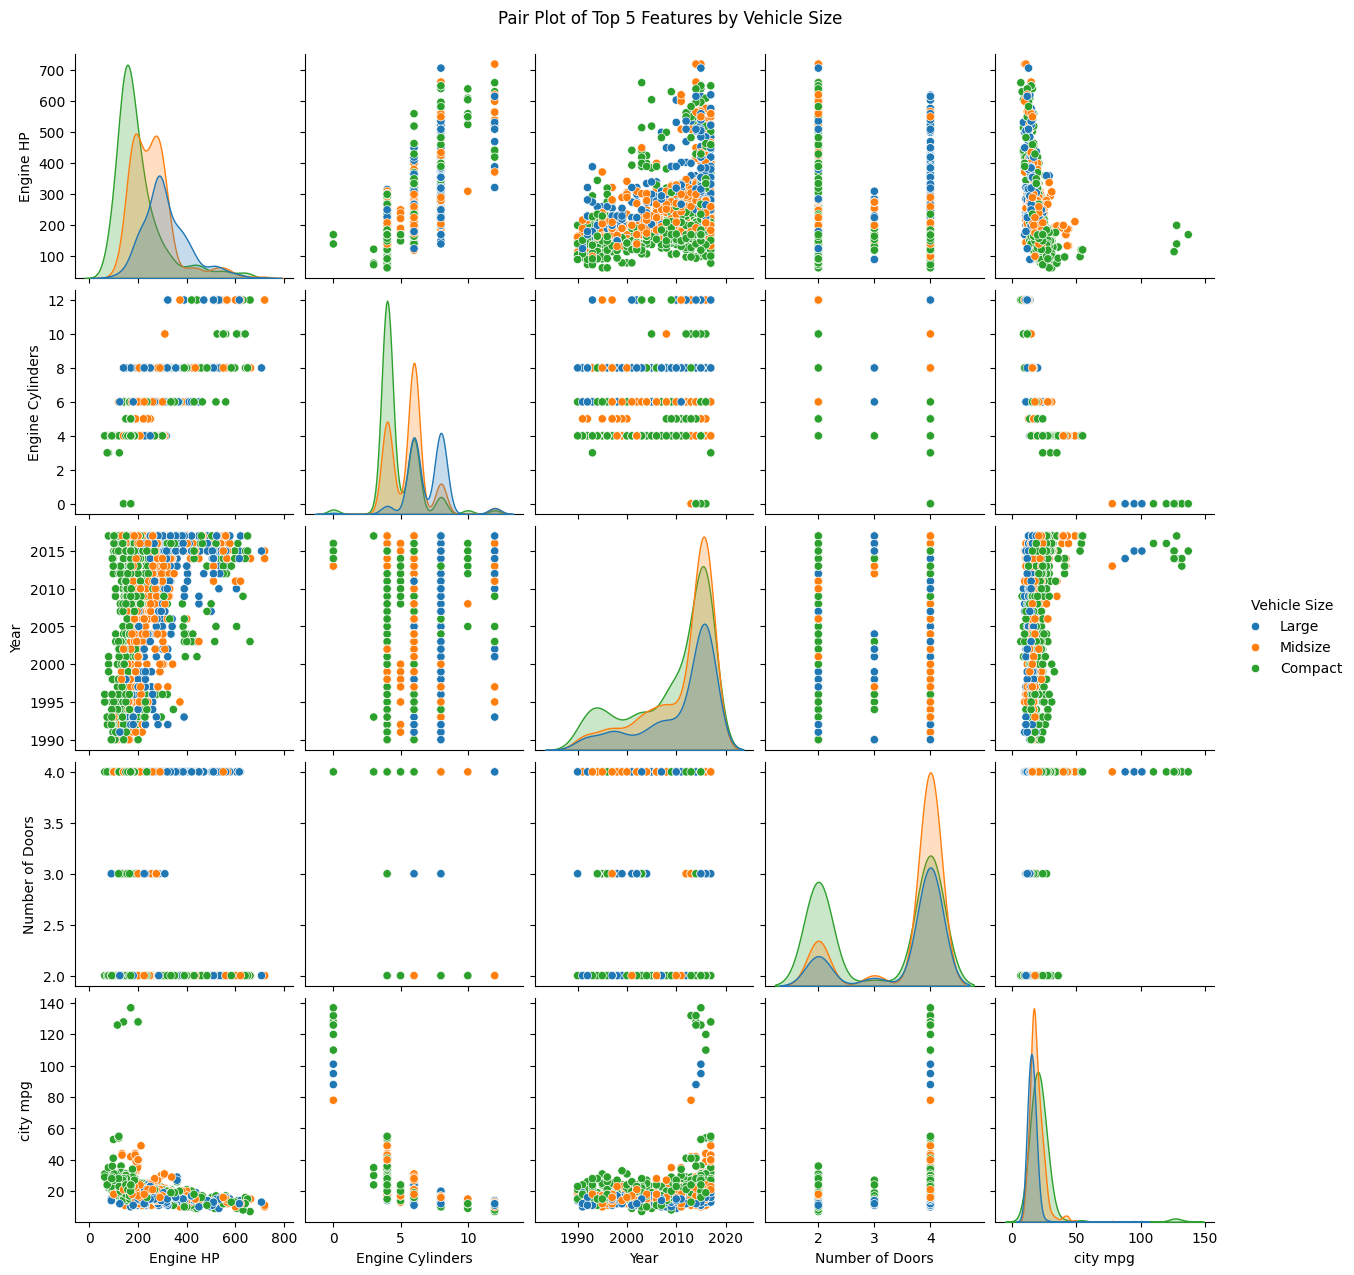

In [ ]:
df_sample = df.sample(2000, random_state=42)

sns.pairplot(df_sample, vars=list(top5_features.keys()), hue='Vehicle Size')
plt.suptitle("Pair Plot of Top 5 Features by Vehicle Size", 
             y=1.02, fontsize=12)

plt.show()

### Pair Plot — Top 5 Features by Vehicle Size

The pair plot reveals that **Engine HP and Engine Cylinders** are the strongest 
individual features for separating Vehicle Size classes — their diagonal KDE 
plots show three distinct peaks for Compact, Midsize and Large. Together, 
Engine HP and Engine Cylinders show clear color clustering in their scatter 
plot with Large cars (blue) concentrated at high HP and high cylinder values 
while Compact cars (green) cluster at lower values. In contrast, **Year and 
Number of Doors** show completely mixed colors in all scatter plots indicating 
they cannot distinguish between vehicle sizes. These findings will directly 
guide feature selection in Phase 5 and model building in Phase 7.

## 2.5 Temporal or spatial patterns

This section substitutes the temporal/spatial plot since the dataset contains 
no timestamp or location column. Instead, violin plots of the two most 
interesting features (Engine HP and MSRP) are produced, stratified by 
Vehicle Size classification target.

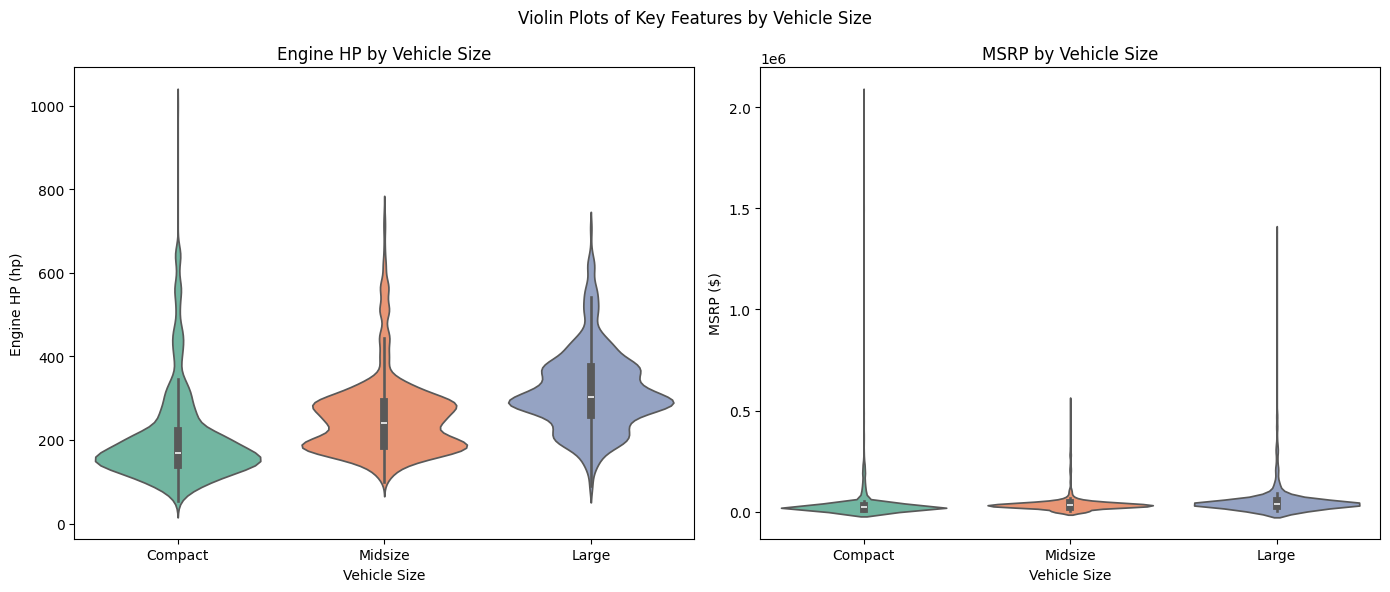

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Engine HP by Vehicle Size
sns.violinplot(x='Vehicle Size', y='Engine HP', 
               data=df, hue='Vehicle Size',
               palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Engine HP by Vehicle Size")
axes[0].set_xlabel("Vehicle Size")
axes[0].set_ylabel("Engine HP (hp)")

# Plot 2 — MSRP by Vehicle Size
sns.violinplot(x='Vehicle Size', y='MSRP', 
               data=df, hue='Vehicle Size',
               palette='Set2', legend=False, ax=axes[1])
axes[1].set_title("MSRP by Vehicle Size")
axes[1].set_xlabel("Vehicle Size")
axes[1].set_ylabel("MSRP ($)")

plt.suptitle("Violin Plots of Key Features by Vehicle Size", fontsize=12)
plt.tight_layout()
plt.show()

## Observations from Violin Plots

**Engine HP violin plot** shows three clearly separated distributions — 
Compact cars are widest around 150–200 HP, Midsize around 200–250 HP, 
and Large around 300 HP with three distinct medians. This confirms that 
Engine HP is a strong differentiator between vehicle size classes.

**MSRP violin plot** shows three violins with almost identical medians 
compressed at the bottom — all three classes have similar price distributions 
with extreme outliers stretching upward. This confirms that MSRP alone 
cannot effectively differentiate between vehicle size classes and is heavily 
influenced by exotic car outliers that will be treated in Phase 3.

**Key Takeaway:** Vehicle Size is best differentiated by Engine HP rather 
than MSRP — Engine HP produces three clearly distinct medians across classes 
while MSRP medians are almost identical across all three vehicle sizes.

## 2.6 EDA Summary Narrative

Exploratory data analysis of the automotive dataset revealed five critical 
findings that will directly inform modelling decisions in later phases.

**Finding 1 — Severe Right Skewness in Key Features:**
MSRP (γ1 = 11.77), highway MPG (γ1 = 7.57), and city mpg (γ1 = 7.11) 
are severely right-skewed, indicating that a small number of extreme values 
— such as exotic cars and electric vehicles — dominate these distributions. 
Log transformation will be applied to MSRP before regression modelling.

**Finding 2 — Extreme Heavy Tails Indicating Dangerous Outliers:**
MSRP (γ2 = 268.81) and highway MPG (γ2 = 181.55) show extremely heavy 
tails confirming the presence of dangerous outliers. In contrast, Number 
of Doors (γ2 = -1.01) has light tails with values tightly clustered 
around 2 and 4. These outliers will be treated using IQR method in Phase 3.

**Finding 3 — Strong Correlations with MSRP:**
Engine HP (r = 0.66) and Engine Cylinders (r = 0.53) show the strongest 
positive correlations with MSRP — more powerful engines with more cylinders 
are significantly more expensive. Highway MPG (r = -0.16) and city mpg 
(r = -0.16) show weak negative correlations — fuel efficient cars tend 
to be cheaper. A critical multicollinearity warning was identified between 
highway MPG and city mpg (r = 0.89) — these two features are nearly 
identical and one may need to be dropped in Phase 5.

**Finding 4 — Extreme MSRP Outliers Distorting Analysis:**
Exotic cars such as Bugatti and Lamborghini with MSRP > $500,000 appear 
as isolated dots in all scatter plots, pulling trend lines upward and 
making them less representative of the majority of cars priced between 
$20,000–$40,000. These outliers will be treated in Phase 3 using IQR 
method before regression modelling in Phase 6.

**Finding 5 — Engine HP Best Differentiates Vehicle Size Classes:**
Box plots and violin plots confirm that Engine HP produces three clearly 
distinct medians across vehicle size classes — Compact (~180 HP), 
Midsize (~240 HP), and Large (~300 HP). In contrast, Year, Number of 
Doors, and Popularity show almost no separation between classes and will 
likely contribute minimally to the classification model in Phase 7. 
Pair plot analysis further confirms that Engine HP and Engine Cylinders 
together provide the strongest visual separation between Compact, 
Midsize and Large vehicles.